In [2]:
import os
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr, kruskal, entropy

import dandelion as ddl

In [3]:
adata_cd8 = sc.read_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/04_TCR/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_scvi_tcr.h5ad")
adata_cd8.var_names_make_unique()
adata_cd8

AnnData object with n_obs × n_vars = 265568 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in 

### Load vdj object

In [4]:
vdj_cd8 = ddl.read_10x_vdj("/scratch/user/s4575250/BIOX7014_Thesis/data/PICA_Batch001-Batch007_tcr_merged/tcr_final/cd8",filename_prefix="filtered")
vdj_cd8

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/core/_core.py:1995: PerformanceWarning: checking membership of a LazyFrame using `in` requires resolving its schema, which is a potentially expensive operation. Use `key in LazyFrame.collect_schema()` to check membership without this warning.


Lazy Dandelion object with n_obs = 253263 and n_contigs = 495145
    data: cell_id, is_cell_10x, sequence_id, high_confidence_10x, sequence_length_10x, locus, v_call, d_call, j_call, c_call, complete_vdj, productive, fwr1_aa, fwr1, cdr1_aa, cdr1, fwr2_aa, fwr2, cdr2_aa, cdr2, fwr3_aa, fwr3, junction_aa, junction, fwr4_aa, fwr4, consensus_count, umi_count, clone_id, raw_consensus_id_10x, exact_subclonotype_id_10x, rearrangement_status
    metadata: cell_id, clone_id, clone_id_rank, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, junction_VDJ_main, junction_VJ_main, umi_count_VDJ_main, umi_count_VJ_main, locus_status, chain_status, rearrangement_status_VDJ, rea

### restrict adata to match vdj object

In [5]:

vdj_ids_cd8 = (
    vdj_cd8.data
    .select("cell_id")
    .unique()
    .collect()
    .to_pandas()["cell_id"]
    .astype(str)
)

rna_ids_cd8 = adata_cd8.obs_names.astype(str)

matched = len(set(vdj_ids_cd8) & set(rna_ids_cd8))
only_in_rna = len(set(rna_ids_cd8) - set(vdj_ids_cd8))
only_in_vdj = len(set(vdj_ids_cd8) - set(rna_ids_cd8))

print("Matched:", matched)
print("Only in RNA:", only_in_rna)
print("Only in VDJ:", only_in_vdj)



Matched: 253263
Only in RNA: 12305
Only in VDJ: 0


In [6]:

mask = adata_cd8.obs_names.isin(vdj_ids_cd8)

obs_cols_keep = [
    "status",
    "assignment",
    "pica_id",
    "pool_id",
    "sequencing_batch",
    "Sex",
    "Age_years",
    "Batch",
    "Age_group",
    "cell_type",
    "pica_cell_type_complete_01_gdT_corrected",
    "leiden"
]

obs_cols_keep = [c for c in obs_cols_keep if c in adata_cd8.obs.columns]

adata_cd8_sub = ad.AnnData(
    obs=adata_cd8.obs.loc[mask, obs_cols_keep].copy()
)
adata_cd8_sub.obs_names = adata_cd8.obs_names[mask].copy()

if "X_umap" in adata_cd8.obsm:
    adata_cd8_sub.obsm["X_umap"] = adata_cd8.obsm["X_umap"][mask].copy()

if "X_scVI" in adata_cd8.obsm:
    adata_cd8_sub.obsm["X_scVI"] = adata_cd8.obsm["X_scVI"][mask].copy()

print(adata_cd8_sub)

AnnData object with n_obs × n_vars = 253263 × 0
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'Sex', 'Age_years', 'Batch', 'Age_group', 'cell_type', 'pica_cell_type_complete_01_gdT_corrected', 'leiden'
    obsm: 'X_umap', 'X_scVI'


In [7]:
# QC: Remove low quality contigs 
vdj_cd8, adata_cd8_sub = ddl.pp.check_contigs(
    vdj_cd8,
    adata=adata_cd8_sub,
    library_type="tr-ab"
)

print(vdj_cd8)
print(adata_cd8_sub)


Filtering contigs...
Marking ambiguous contigs...
Initializing DandelionPolars object...


/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/core/_core.py:1995: PerformanceWarning: checking membership of a LazyFrame using `in` requires resolving its schema, which is a potentially expensive operation. Use `key in LazyFrame.collect_schema()` to check membership without this warning.


Lazy Dandelion object with n_obs = 253263 and n_contigs = 518798
    data: cell_id, is_cell_10x, sequence_id, high_confidence_10x, sequence_length_10x, locus, v_call, d_call, j_call, c_call, complete_vdj, productive, fwr1_aa, fwr1, cdr1_aa, cdr1, fwr2_aa, fwr2, cdr2_aa, cdr2, fwr3_aa, fwr3, junction_aa, junction, fwr4_aa, fwr4, consensus_count, umi_count, clone_id, raw_consensus_id_10x, exact_subclonotype_id_10x, rearrangement_status, extra, ambiguous
    metadata: cell_id, clone_id, clone_id_rank, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, productive_VDJ, productive_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, productive_VDJ_main, productive_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, junction_VDJ_main, junction_VJ_main, umi_co

In [8]:
# Compute clone sizes
ddl.tl.clone_size(vdj_cd8)
vdj_cd8

Lazy Dandelion object with n_obs = 253263 and n_contigs = 518798
    data: cell_id, is_cell_10x, sequence_id, high_confidence_10x, sequence_length_10x, locus, v_call, d_call, j_call, c_call, complete_vdj, productive, fwr1_aa, fwr1, cdr1_aa, cdr1, fwr2_aa, fwr2, cdr2_aa, cdr2, fwr3_aa, fwr3, junction_aa, junction, fwr4_aa, fwr4, consensus_count, umi_count, clone_id, raw_consensus_id_10x, exact_subclonotype_id_10x, rearrangement_status, extra, ambiguous
    metadata: cell_id, clone_id, clone_id_rank, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, productive_VDJ, productive_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, productive_VDJ_main, productive_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, junction_VDJ_main, junction_VJ_main, umi_co

In [9]:
# compute expanded vs non-expanded clone size
ddl.tl.clone_size(vdj_cd8, max_size=2)

In [10]:
vdj_cd8._metadata.collect()["clone_id_size_max_2"].value_counts()

clone_id_size_max_2,count
str,u32
""">= 2""",251243
"""1""",2020


### Transfer VDJ information into Scanpy object

In [11]:
ddl.tl.transfer(adata_cd8_sub, vdj_cd8)
print([c for c in adata_cd8_sub.obs.columns if "clone" in c.lower() or "contig" in c.lower()])

['has_contig', 'clone_id', 'clone_id_rank', 'clone_id_size', 'clone_id_size_prop', 'clone_id_size_category', 'clone_id_size_max_2']


In [12]:
print(adata_cd8_sub.obs["clone_id_size_category"].astype(str).value_counts(dropna=False))
print(adata_cd8_sub.obs["clone_id_size"].value_counts(dropna=False).head(20))

clone_id_size_category
Rare      217297
Medium     16473
Small      12418
Large       7075
Name: count, dtype: int64
clone_id_size
8       31320
7       29302
9       28638
6       23454
10      22800
5       17320
11      16918
12      10752
4       10460
13       6149
3        5928
4529     4529
14       3080
2        3030
2546     2546
1        2020
15       1980
1890     1890
1607     1607
16       1168
Name: count, dtype: int64


In [13]:
pd.crosstab(
    adata_cd8_sub.obs["clone_id_size_category"],
    adata_cd8_sub.obs["clone_id_size"]
)

clone_id_size,1,2,3,4,5,6,7,8,9,10,...,740,809,876,948,1049,1134,1607,1890,2546,4529
clone_id_size_category,,,,,,,,,,,,,,,,,,,,,
Large,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2546,4529
Medium,0,0,0,0,0,0,0,0,0,0,...,740,809,876,948,1049,1134,1607,1890,0,0
Rare,2020,3030,5928,10460,17320,23454,29302,31320,28638,22800,...,0,0,0,0,0,0,0,0,0,0
Small,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='clone_id_size', ylabel='Count'>

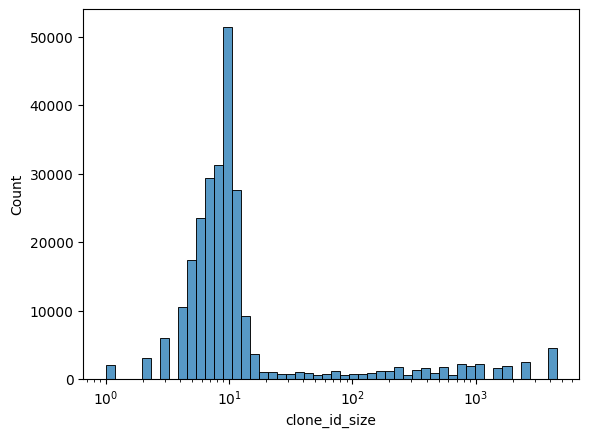

In [14]:
sns.histplot(
    adata_cd8_sub.obs["clone_id_size"],
    bins=50,
    log_scale=True
)

In [15]:
adata_cd8_sub

AnnData object with n_obs × n_vars = 253263 × 0
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'Sex', 'Age_years', 'Batch', 'Age_group', 'cell_type', 'pica_cell_type_complete_01_gdT_corrected', 'leiden', 'has_contig', 'clone_id', 'clone_id_rank', 'locus_VDJ', 'locus_VJ', 'v_call_VDJ', 'v_call_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'productive_VDJ', 'productive_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'junction_VDJ', 'junction_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'locus_VDJ_main', 'locus_VJ_main', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'productive_VDJ_main', 'productive_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ', 'clone_id_size', 'clone_id_size_prop', 'c

## Clone annotation

In [16]:
# Use existing clone size category already stored in the object

celltype_col = "pica_cell_type_complete_01_gdT_corrected"
clone_cat_col = "clone_id_size_category"

clone_order = ["Rare", "Small", "Medium", "Large"]

# Keep your existing annotation, but standardise it as an ordered categorical
adata_cd8_sub.obs[clone_cat_col] = pd.Categorical(
    adata_cd8_sub.obs[clone_cat_col].astype("object"),
    categories=clone_order,
    ordered=True,
)

adata_tcr = adata_cd8_sub[
    adata_cd8_sub.obs["clone_id"].notna()
].copy()

print("TCR cells with clone_id:", adata_tcr.n_obs)
print("Unique clonotypes:", adata_tcr.obs["clone_id"].nunique())
print("Clone size category counts:")
print(adata_tcr.obs[clone_cat_col].value_counts(dropna=False))



TCR cells with clone_id: 253263
Unique clonotypes: 32737
Clone size category counts:
clone_id_size_category
Rare      217297
Medium     16473
Small      12418
Large       7075
Name: count, dtype: int64


In [17]:
# use Dandelion labels to make binary label
adata_tcr.obs["expanded_status"] = adata_tcr.obs["clone_id_size_max_2"].map({
    "1": "Non-expanded",
    ">= 2": "Expanded"
})

print(adata_tcr.obs["expanded_status"].value_counts(dropna=False))

expanded_status
Expanded        251243
Non-expanded      2020
Name: count, dtype: int64


In [18]:
print(adata_tcr)

AnnData object with n_obs × n_vars = 253263 × 0
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'Sex', 'Age_years', 'Batch', 'Age_group', 'cell_type', 'pica_cell_type_complete_01_gdT_corrected', 'leiden', 'has_contig', 'clone_id', 'clone_id_rank', 'locus_VDJ', 'locus_VJ', 'v_call_VDJ', 'v_call_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'productive_VDJ', 'productive_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'junction_VDJ', 'junction_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'locus_VDJ_main', 'locus_VJ_main', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'productive_VDJ_main', 'productive_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ', 'clone_id_size', 'clone_id_size_prop', 'c

In [19]:
age_bins = [0, 3, 6, 10, 14, 18]
age_labels = ["0–3", "4–6", "7–10", "11–14", "15–18"]

adata_tcr.obs["Age_group"] = pd.cut(
        adata_tcr.obs["Age_years"],
        bins= age_bins,
        labels= age_labels,
        right=False
    )

adata_tcr.obs["Age_group"] = adata_tcr.obs["Age_group"].cat.set_categories(age_labels)

In [20]:
pd.crosstab(
    adata_tcr.obs["clone_id_size_category"],
    adata_tcr.obs["expanded_status"]
)

expanded_status,Expanded,Non-expanded
clone_id_size_category,,
Rare,215277,2020
Small,12418,0
Medium,16473,0
Large,7075,0


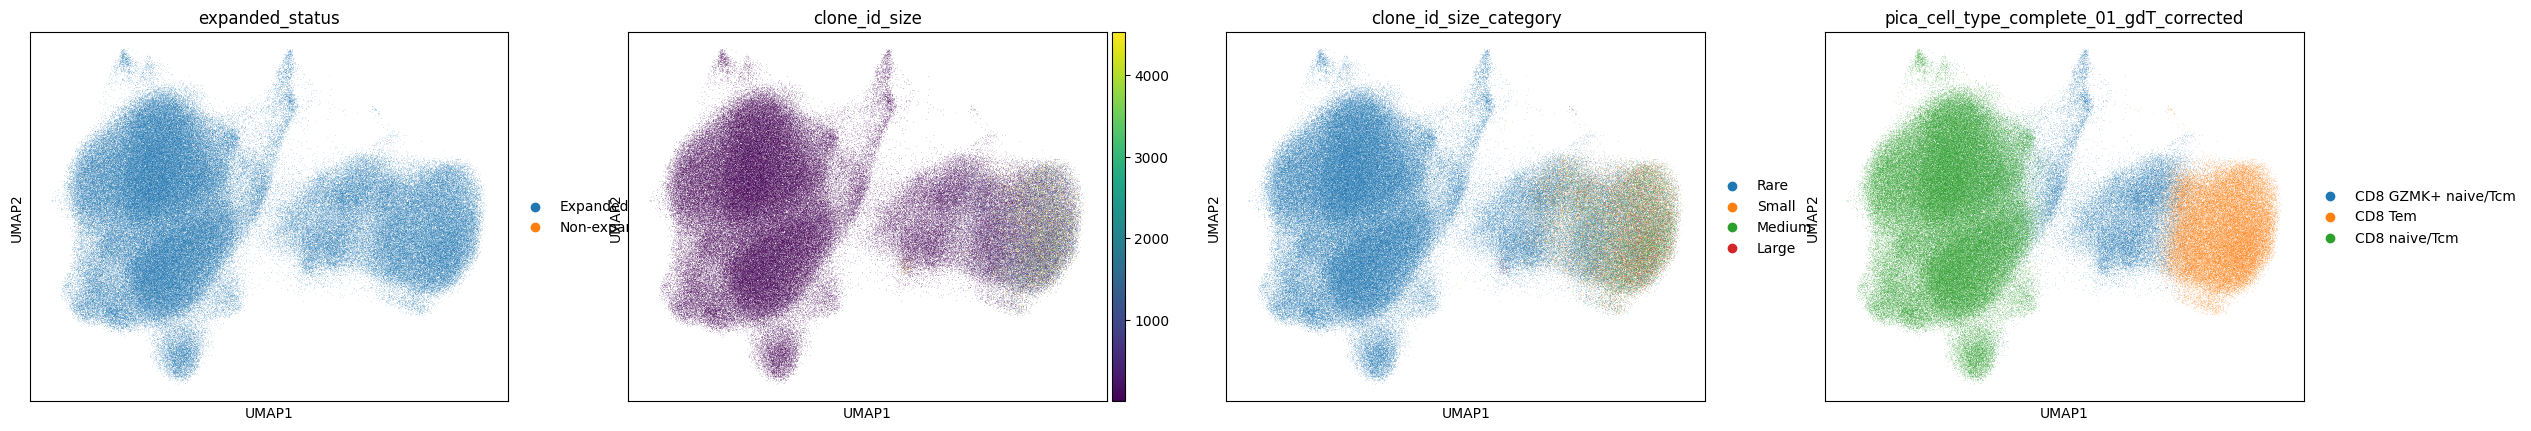

In [21]:
sc.pl.umap(
    adata_tcr,
    color=[
        "expanded_status",
        "clone_id_size",
        clone_cat_col,
        celltype_col,
    ],
    na_in_legend=False,
)

## visualization

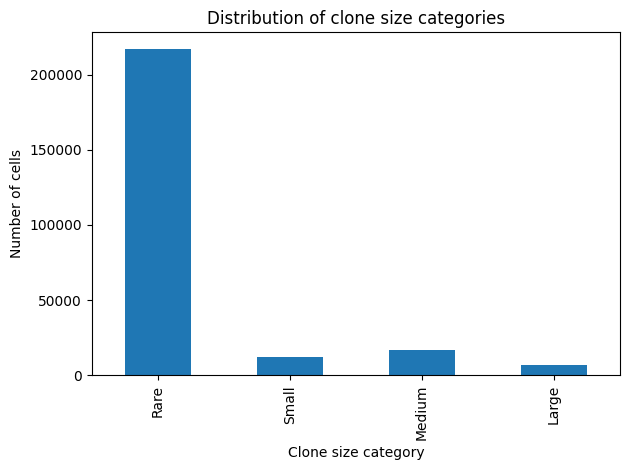

In [22]:
# Clone size distribution
clone_counts = (
    adata_tcr.obs[clone_cat_col]
    .value_counts(dropna=False)
    .reindex(clone_order)
)

clone_counts.plot(kind="bar")
plt.ylabel("Number of cells")
plt.xlabel("Clone size category")
plt.title("Distribution of clone size categories")
plt.tight_layout()
plt.show()

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:257: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


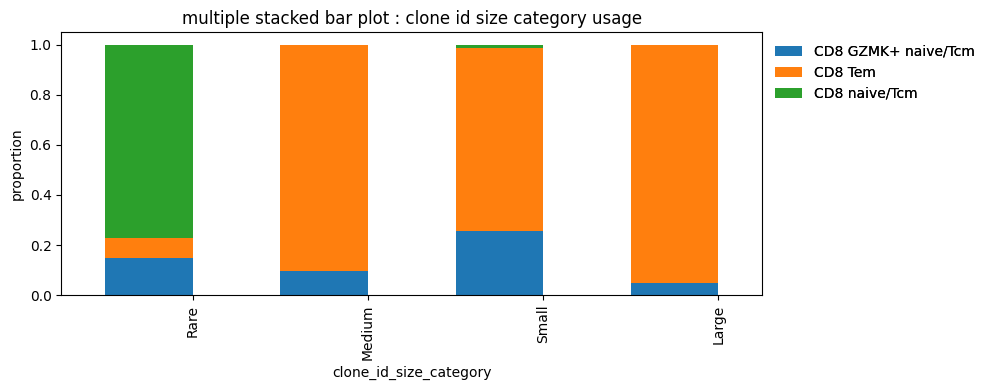

In [23]:
ddl.pl.stackedbarplot(
    adata_tcr,
    group_by=celltype_col,
    color=clone_cat_col,
    normalize=True,
    figsize=(10, 4),
)
plt.legend(bbox_to_anchor=(1, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()


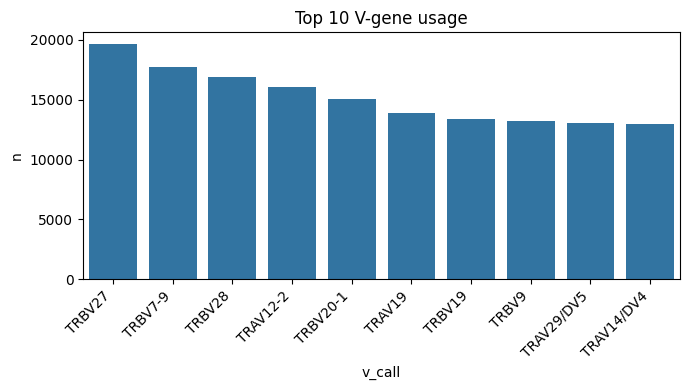

In [24]:
vdj_df = vdj_cd8.data.select(["cell_id", "v_call"]).collect().to_pandas()
vdj_df["cell_id"] = vdj_df["cell_id"].astype(str).str.replace("-1$", "", regex=True)

v_usage = (
    vdj_df.dropna(subset=["v_call"])
    .groupby("v_call")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="n")
)

plt.figure(figsize=(7, 4))
sns.barplot(data=v_usage, x="v_call", y="n")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 V-gene usage")
plt.tight_layout()
plt.show()

## Donor level diversity estimation
- Shannon diversity
- Simpson diversity
- Inverse diversity
- Clonality
- Richness

In [25]:
# create donor level summary
adata_tcr.obs["expanded_flag"] = (
    adata_tcr.obs["clone_id_size_category"]
    .map({"Rare": 0, "Small": 1})
    .astype(float)
)

def shannon_from_clone_ids(clone_ids):
    counts = clone_ids.value_counts()
    p = counts / counts.sum()
    return entropy(p)

def simpson_from_clone_ids(clone_ids):
    counts = clone_ids.value_counts()
    p = counts / counts.sum()
    return np.sum(p ** 2)

donor_summary = (
    adata_tcr.obs.dropna(subset=["pica_id"])
    .groupby("pica_id")
    .agg(
        n_tcr_cells=("clone_id", "size"),
        n_clonotypes=("clone_id", pd.Series.nunique),
        Age_years=("Age_years", "first"),
        Age_group=("Age_group", "first"),
        Sex=("Sex", "first"),
    )
)

# add Shannon / Simpson / Clonality / expanded proportion only on non-null clone_id
clone_nonnull = adata_tcr.obs.dropna(subset=["pica_id", "clone_id"]).copy()

shannon_by_donor = clone_nonnull.groupby("pica_id")["clone_id"].apply(shannon_from_clone_ids)
simpson_by_donor = clone_nonnull.groupby("pica_id")["clone_id"].apply(simpson_from_clone_ids)

donor_summary["Shannon"] = shannon_by_donor
donor_summary["Simpson"] = simpson_by_donor
donor_summary["Clonality"] = 1 - donor_summary["Simpson"]

prop_expanded = (
    adata_tcr.obs
    .groupby("pica_id")["expanded_flag"]
    .mean()
)

donor_summary["prop_expanded"] = prop_expanded


donor_summary = donor_summary.reset_index()
display(donor_summary.head())

/scratch/temp/24288055/ipykernel_894321/1134017701.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/temp/24288055/ipykernel_894321/1134017701.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


/scratch/temp/24288055/ipykernel_894321/1134017701.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/temp/24288055/ipykernel_894321/1134017701.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,pica_id,n_tcr_cells,n_clonotypes,Age_years,Age_group,Sex,Shannon,Simpson,Clonality,prop_expanded
0,PICA0001,694,619,2.09,0–3,Male,6.319898,0.002375,0.997625,0.056911
1,PICA0002,379,376,15.09,15–18,Male,5.926563,0.002680,0.997320,0.034483
2,PICA0003,433,421,0.83,0–3,Male,6.023498,0.002523,0.997477,0.031175
3,PICA0008,2806,2146,9.70,7–10,Female,7.367626,0.001614,0.998386,0.161709
4,PICA0009,2696,1866,4.76,4–6,Female,6.802950,0.007908,0.992092,0.111996


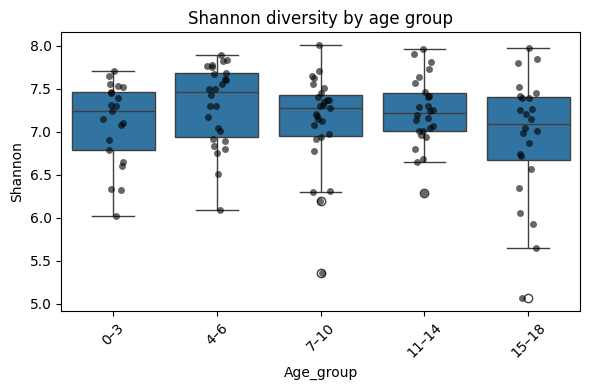

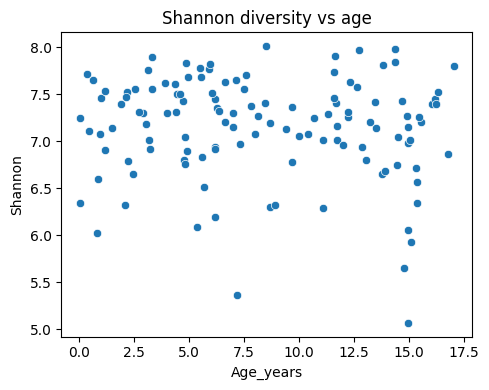

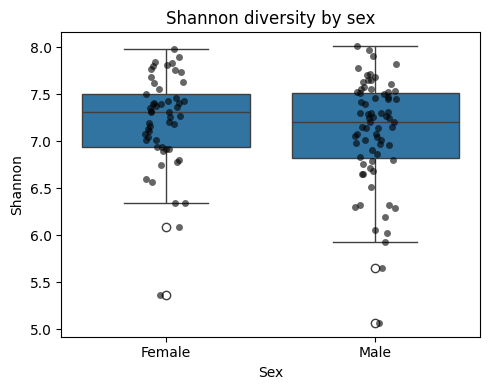

In [26]:
# shannon diversity
plt.figure(figsize=(6, 4))
sns.boxplot(data=donor_summary, x="Age_group", y="Shannon")
sns.stripplot(data=donor_summary, x="Age_group", y="Shannon", color="black", alpha=0.6)
plt.xticks(rotation=45)
plt.title("Shannon diversity by age group")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.scatterplot(data=donor_summary, x="Age_years", y="Shannon")
plt.title("Shannon diversity vs age")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.boxplot(data=donor_summary, x="Sex", y="Shannon")
sns.stripplot(data=donor_summary, x="Sex", y="Shannon", color="black", alpha=0.6)
plt.title("Shannon diversity by sex")
plt.tight_layout()
plt.show()

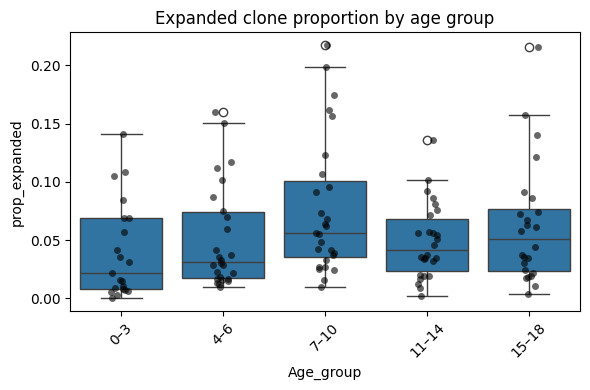

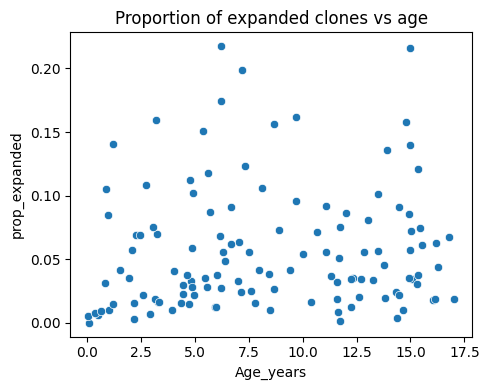

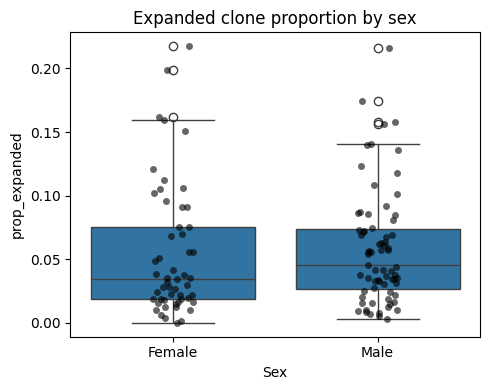

In [27]:
# expanded clone proportion
plt.figure(figsize=(6, 4))
sns.boxplot(data=donor_summary, x="Age_group", y="prop_expanded")
sns.stripplot(data=donor_summary, x="Age_group", y="prop_expanded", color="black", alpha=0.6)
plt.xticks(rotation=45)
plt.title("Expanded clone proportion by age group")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.scatterplot(data=donor_summary, x="Age_years", y="prop_expanded")
plt.title("Proportion of expanded clones vs age")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.boxplot(data=donor_summary, x="Sex", y="prop_expanded")
sns.stripplot(data=donor_summary, x="Sex", y="prop_expanded", color="black", alpha=0.6)
plt.title("Expanded clone proportion by sex")
plt.tight_layout()
plt.show()


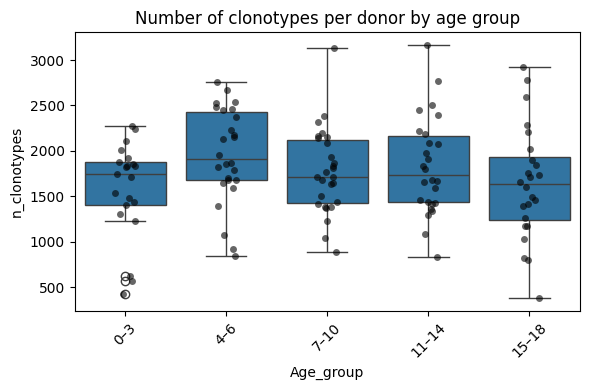

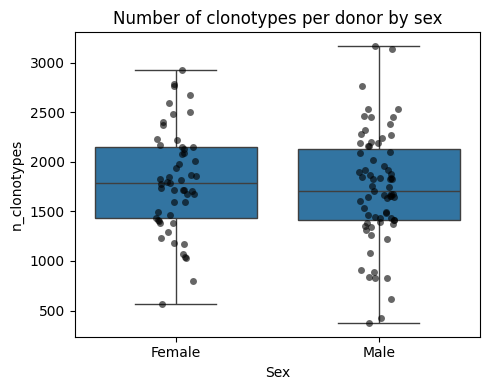

In [28]:
# clonotype richness
plt.figure(figsize=(6, 4))
sns.boxplot(data=donor_summary, x="Age_group", y="n_clonotypes")
sns.stripplot(data=donor_summary, x="Age_group", y="n_clonotypes", color="black", alpha=0.6)
plt.xticks(rotation=45)
plt.title("Number of clonotypes per donor by age group")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.boxplot(data=donor_summary, x="Sex", y="n_clonotypes")
sns.stripplot(data=donor_summary, x="Sex", y="n_clonotypes", color="black", alpha=0.6)
plt.title("Number of clonotypes per donor by sex")
plt.tight_layout()
plt.show()

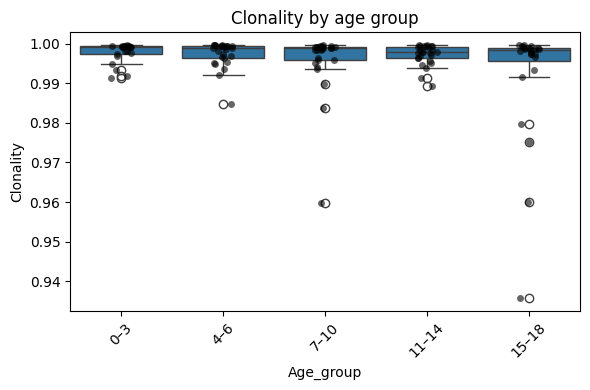

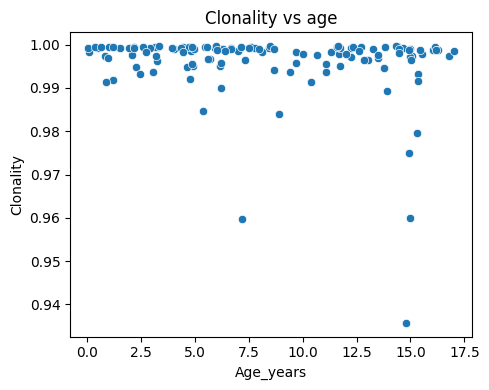

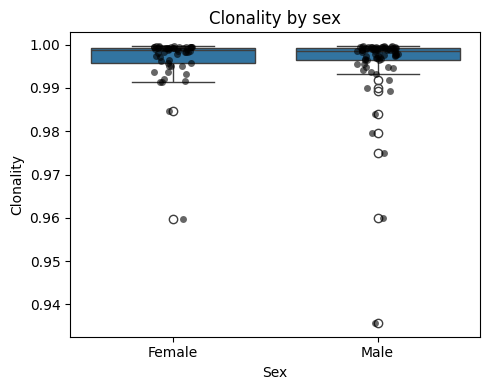

In [29]:
# clonality
plt.figure(figsize=(6, 4))
sns.boxplot(data=donor_summary, x="Age_group", y="Clonality")
sns.stripplot(data=donor_summary, x="Age_group", y="Clonality", color="black", alpha=0.6)
plt.xticks(rotation=45)
plt.title("Clonality by age group")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.scatterplot(data=donor_summary, x="Age_years", y="Clonality")
plt.title("Clonality vs age")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.boxplot(data=donor_summary, x="Sex", y="Clonality")
sns.stripplot(data=donor_summary, x="Sex", y="Clonality", color="black", alpha=0.6)
plt.title("Clonality by sex")
plt.tight_layout()
plt.show()

/scratch/temp/24288055/ipykernel_894321/3981203694.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/temp/24288055/ipykernel_894321/3981203694.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


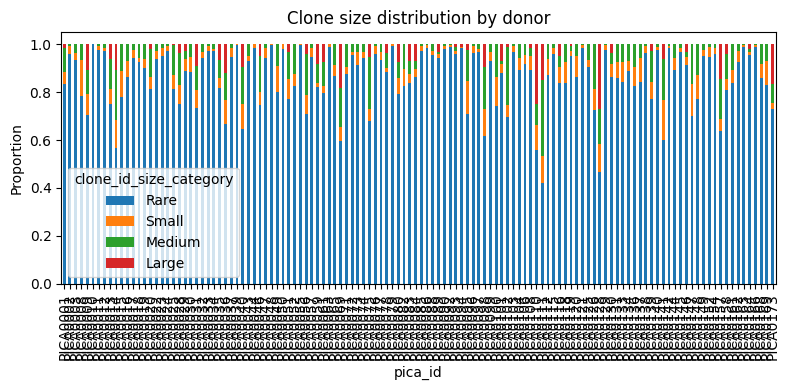

In [30]:
# clone size distribution
clone_dist = (
    adata_tcr.obs.dropna(subset=["pica_id", clone_cat_col])
    .groupby(["pica_id", clone_cat_col])
    .size()
    .rename("n_cells")
    .reset_index()
)

donor_totals = clone_dist.groupby("pica_id")["n_cells"].sum().rename("total_cells").reset_index()
clone_dist = clone_dist.merge(donor_totals, on="pica_id", how="left")
clone_dist["proportion"] = clone_dist["n_cells"] / clone_dist["total_cells"]

pivot_df = clone_dist.pivot(index="pica_id", columns=clone_cat_col, values="proportion").fillna(0)
cols = [c for c in clone_order if c in pivot_df.columns]
pivot_df = pivot_df[cols]

pivot_df.plot(kind="bar", stacked=True, figsize=(8, 4))
plt.ylabel("Proportion")
plt.title("Clone size distribution by donor")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


/scratch/temp/24288055/ipykernel_894321/2041202451.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


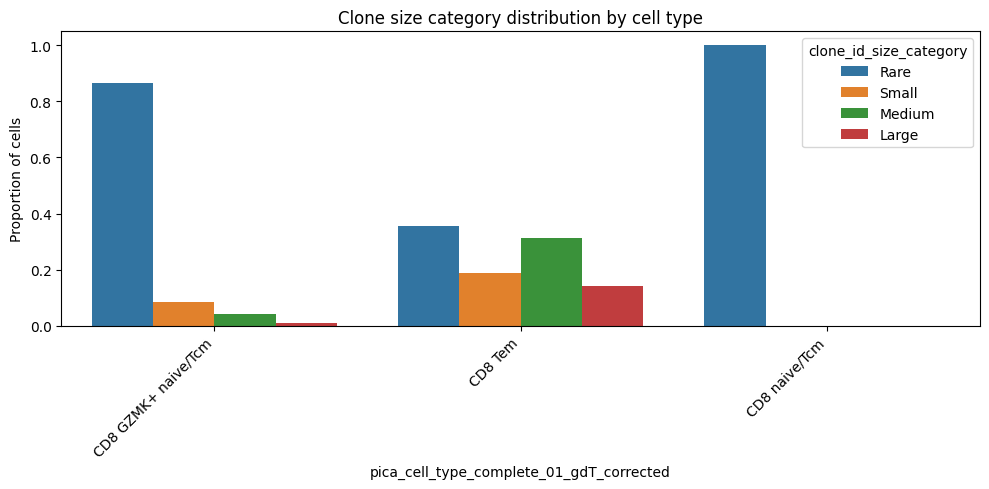

In [31]:
# cell type
clone_cat_prop = (
    adata_tcr.obs.groupby(celltype_col)[clone_cat_col]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=clone_cat_prop,
    x=celltype_col,
    y="proportion",
    hue=clone_cat_col,
    hue_order=clone_order
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion of cells")
plt.xlabel(celltype_col)
plt.title("Clone size category distribution by cell type")
plt.tight_layout()
plt.show()



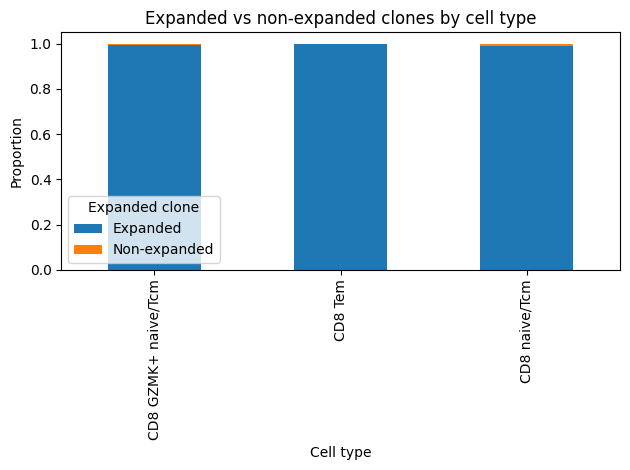

In [32]:
# Expanded clones by cell type
expanded_by_celltype = pd.crosstab(
    adata_tcr.obs[celltype_col],
    adata_tcr.obs["expanded_status"],
    normalize="index"
)

expanded_by_celltype.plot(kind="bar", stacked=True)
plt.ylabel("Proportion")
plt.xlabel("Cell type")
plt.title("Expanded vs non-expanded clones by cell type")
plt.legend(title="Expanded clone")
plt.tight_layout()
plt.show()

## Expanded clones visualisation

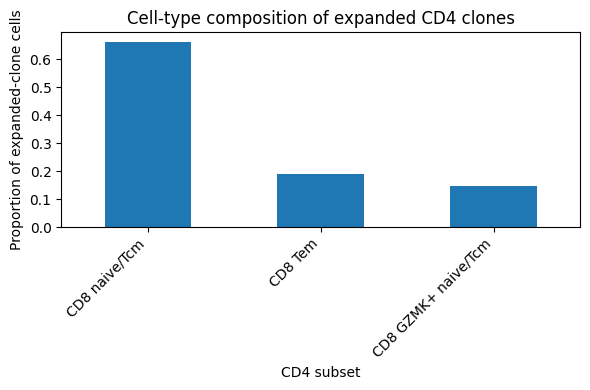

In [48]:
expanded_only = adata_tcr.obs[
    adata_tcr.obs["expanded_status"] == "Expanded"
]

expanded_celltype_prop = (
    expanded_only[celltype_col]
    .value_counts(normalize=True)
)

expanded_celltype_prop.plot(kind="bar", figsize=(6, 4))

plt.ylabel("Proportion of expanded-clone cells")
plt.xlabel("CD4 subset")
plt.title("Cell-type composition of expanded CD4 clones")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/scratch/temp/24288055/ipykernel_894321/2256592552.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


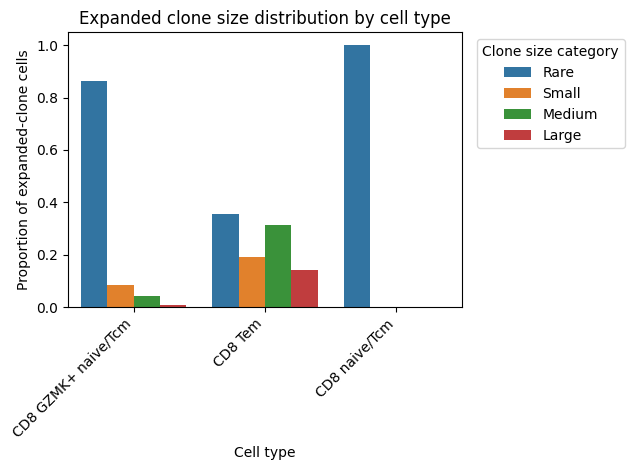

In [38]:
# cell type of expanded clones
plot_df = adata_tcr.obs[
    adata_tcr.obs[clone_cat_col].isin(clone_order)
].copy()

clone_cat_prop = (
    plot_df
    .groupby(celltype_col)[clone_cat_col]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

sns.barplot(
    data=clone_cat_prop,
    x=celltype_col,
    y="proportion",
    hue=clone_cat_col,
    hue_order=clone_order
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion of expanded-clone cells")
plt.xlabel("Cell type")
plt.title("Expanded clone size distribution by cell type")
plt.legend(title="Clone size category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

/scratch/temp/24288055/ipykernel_894321/1739747199.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/temp/24288055/ipykernel_894321/1739747199.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


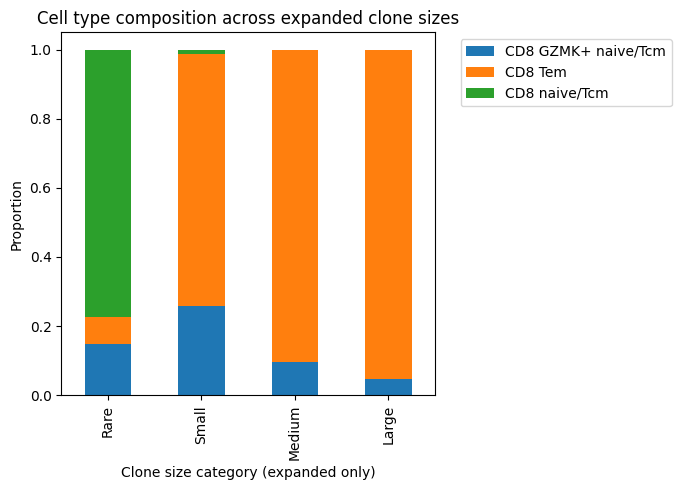

In [37]:
# keep only expanded clones
expanded_cells = adata_tcr.obs[
    adata_tcr.obs["expanded_status"] == "Expanded"
]

# compute proportions
comp = (
    expanded_cells
    .groupby([clone_cat_col, celltype_col])
    .size()
    .rename("n_cells")
    .reset_index()
)

# convert to proportions within each clone size category
comp["prop"] = comp.groupby(clone_cat_col)["n_cells"].transform(lambda x: x / x.sum())

# plot
pivot = comp.pivot(
    index=clone_cat_col,
    columns=celltype_col,
    values="prop"
).fillna(0)

pivot.plot(kind="bar", stacked=True, figsize=(7, 5))

plt.ylabel("Proportion")
plt.xlabel("Clone size category (expanded only)")
plt.title("Cell type composition across expanded clone sizes")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

,CD8 GZMK+ naive/Tcm,CD8 Tem,CD8 naive/Tcm
CD8 GZMK+ naive/Tcm,1.000000,0.034496,0.000059
CD8 Tem,0.034496,1.000000,0.000005
CD8 naive/Tcm,0.000059,0.000005,1.000000


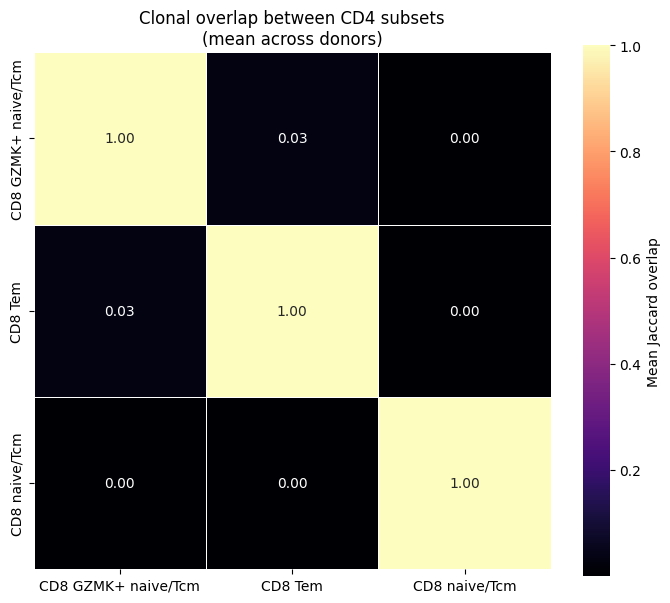

In [34]:
df_overlap = adata_tcr.obs[[celltype_col, "clone_id", "pica_id"]].copy()
df_overlap = df_overlap.dropna(subset=[celltype_col, "clone_id", "pica_id"])

preferred_order = ["Treg", "CD4 cytoT", "CD4 Tem", "CD4 naive/Tcm", "Tfh"]
celltypes = [ct for ct in preferred_order if ct in df_overlap[celltype_col].unique()]
remaining = sorted([ct for ct in df_overlap[celltype_col].unique() if ct not in celltypes])
celltypes = celltypes + remaining

donors = sorted(df_overlap["pica_id"].unique())

donor_mats = []
pairwise_records = []

for donor in donors:
    df_d = df_overlap[df_overlap["pica_id"] == donor].copy()

    clone_sets = {
        ct: set(df_d.loc[df_d[celltype_col] == ct, "clone_id"])
        for ct in celltypes
    }

    mat = pd.DataFrame(index=celltypes, columns=celltypes, dtype=float)

    for ct1 in celltypes:
        for ct2 in celltypes:
            s1 = clone_sets[ct1]
            s2 = clone_sets[ct2]
            inter = s1 & s2
            union = s1 | s2
            jaccard = len(inter) / len(union) if len(union) > 0 else np.nan
            mat.loc[ct1, ct2] = jaccard

            pairwise_records.append({
                "pica_id": donor,
                "celltype_1": ct1,
                "celltype_2": ct2,
                "n_shared_clones": len(inter),
                "n_union_clones": len(union),
                "jaccard_overlap": jaccard,
            })

    donor_mats.append(mat)

overlap_mean = pd.concat(donor_mats).groupby(level=0).mean()
overlap_mean = overlap_mean.loc[celltypes, celltypes]
overlap_long = pd.DataFrame(pairwise_records)

display(overlap_mean)

plt.figure(figsize=(7, 6))
sns.heatmap(
    overlap_mean,
    cmap="magma",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Mean Jaccard overlap"},
)
plt.title("Clonal overlap between CD4 subsets\n(mean across donors)")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()